# População e amostra



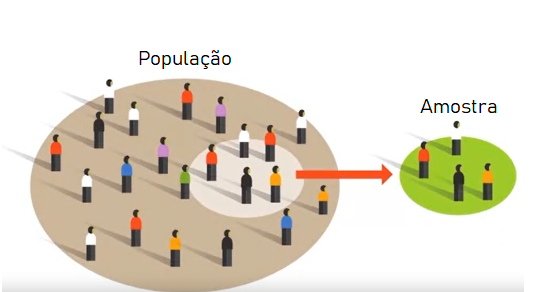

In [1]:
from IPython.display import Image
Image('Pop_e_amostra.png')

In [3]:
import pandas as pd
import numpy as np

In [23]:
# Criando uma população com N=10 dados

dados = pd.DataFrame()
dados['Populacao'] = [1.55, 1.48, 1.85, 1.20, 1.19, 1.13, 1.72, 1.16, 1.50, 1.60, 1.76]
print(dados)

    Populacao
0        1.55
1        1.48
2        1.85
3        1.20
4        1.19
5        1.13
6        1.72
7        1.16
8        1.50
9        1.60
10       1.76


In [7]:
round(dados['Populacao'].mean(), 2) # média populacional 

1.44

In [12]:
#Variancia populacional 
round(dados['Populacao'].var(ddof=0), 5)

0.0584

Diferentes maneiras de se amostrar a partir da população


In [8]:
# Retirando uma amostra de tamanho n=5 com substituição 

amostra_com_repeticao = dados['Populacao'].sample(5, replace=True)
print(amostra_com_repeticao.to_string())

7    1.16
2    1.85
3    1.20
9    1.60
0    1.55


In [9]:
# Retirando uma amostra de tamanho n=5 sem substituição 

amostra_sem_repeticao = dados['Populacao'].sample(5, replace=False)
print(amostra_sem_repeticao)

5    1.13
4    1.19
2    1.85
1    1.48
6    1.72
Name: Populacao, dtype: float64



# Parâmetros e estatísticas

Os parâmetros se referem à população enquanto que as estatísticas se referem às amostras. <br><br> 





Parâmetros populacionais:<br>
Média populacional:
$$
\mu=\frac{\sum_{i=1}^{N}X_i}{N}
$$
Variância populacional:
$$
\sigma^2=\frac{\sum_{i=1}^{N}(X_i-\mu)^2}{N}
$$

In [24]:
# Cálculo da média e variância populacionais

media_populacional = dados['Populacao'].mean() # media populacional 
variancia_populacional = dados['Populacao'].var(ddof=0) #variancia populacional 

print('A média populacional é: ', round(media_populacional, 2), '\n')
print('A variância populacional é:', round(variancia_populacional, 5))

A média populacional é:  1.47 

A variância populacional é: 0.06166


Estimadores amostrais: <br>
Média amostral:
$$
\hat\mu=\frac{\sum_{i=1}^{N}X_i}{n}
$$
Variância amostral:
$$
\hat\sigma^2=\frac{\sum_{i=1}^{n}(X_i-\mu)^2}{n-1}
$$


In [20]:
# Cálculo da média amostral e desvio padrão amostral. Tamanho da amostra: n=10
# A cada execução do código abaixo uma nova média e uma nova variância serão gerados

amostra = dados['Populacao'].sample(10, replace=True)
print(amostra.to_string(),'\n')

media_amostral = amostra.mean()
variancia_amostral = amostra.var(ddof=1)

print('A média amostral é', round(media_amostral,2))
print('A variância amostral é', round(variancia_amostral,2))

0    47
9    60
9    60
8    50
9    60
5    13
0    47
4    19
8    50
7    16 

A média amostral é 42.2
A variância amostral é 355.07


**Vício**<br>
Um estimador é não viciado ou não viesado para um parâmetro $\theta$ se $E(\hat\theta)=\theta$. Em outras palavras, um estimador é não viciado se o seu valor esperado coincide com o parâmetro de interesse. 

**Consistência**<br>
Um estimador $\hat\theta$ é consistente, se, à medida que o tamanho $n$ da amostra aumenta, seu valor esperado converge para o parâmetro de interesse e sua variância converge para zero. Ou seja, $\hat\theta$ é consistente se as duas propriedades seguintes são satisfeitas:<br><br>
$$
(i)\quad \lim_{n\rightarrow\infty}E(\hat\theta)=\theta
$$
<br> e <br>
$$
(ii)\quad \lim_{n\rightarrow\infty}Var(\hat\theta)=0.
$$


# Média de um estimador não viesado

In [50]:
qtd_amostras = 1000
colecao_de_variancias_amostrais = [dados['Populacao'].sample(10, replace=True).var(ddof=1)\
                                   for i in range(qtd_amostras)]
print(colecao_de_variancias_amostrais)

[0.06436000000000003, 0.04964000000000002, 0.051410000000000025, 0.04511555555555556, 0.058498888888888906, 0.07301000000000002, 0.061912222222222243, 0.043151111111111126, 0.07540555555555557, 0.05686666666666668, 0.049845555555555573, 0.06167222222222225, 0.08341000000000004, 0.06379555555555558, 0.08228444444444445, 0.062222222222222255, 0.04289000000000001, 0.05749888888888891, 0.05279555555555558, 0.04972111111111114, 0.04373444444444446, 0.04756000000000002, 0.07297333333333338, 0.04987666666666668, 0.04286777777777779, 0.03648444444444446, 0.03815111111111113, 0.060143333333333354, 0.05642333333333335, 0.07001000000000002, 0.020204444444444452, 0.05371222222222224, 0.0702266666666667, 0.10965444444444448, 0.06257333333333336, 0.06321000000000004, 0.08987222222222228, 0.053876666666666684, 0.0973955555555556, 0.05837333333333335, 0.0799655555555556, 0.07082777777777778, 0.07589333333333335, 0.08806222222222225, 0.08934333333333339, 0.08342666666666673, 0.09500000000000004, 0.1043

In [51]:
colecao = pd.DataFrame(colecao_de_variancias_amostrais)
print(colecao)
print(round(colecao[0].mean(),6),'\n\n', round(variancia_populacional,6))

            0
0    0.064360
1    0.049640
2    0.051410
3    0.045116
4    0.058499
5    0.073010
6    0.061912
7    0.043151
8    0.075406
9    0.056867
10   0.049846
11   0.061672
12   0.083410
13   0.063796
14   0.082284
15   0.062222
16   0.042890
17   0.057499
18   0.052796
19   0.049721
20   0.043734
21   0.047560
22   0.072973
23   0.049877
24   0.042868
25   0.036484
26   0.038151
27   0.060143
28   0.056423
29   0.070010
..        ...
970  0.071351
971  0.049862
972  0.060751
973  0.033846
974  0.066484
975  0.075573
976  0.072557
977  0.043628
978  0.090360
979  0.068116
980  0.067440
981  0.077832
982  0.033373
983  0.050672
984  0.065267
985  0.086668
986  0.048961
987  0.090449
988  0.058188
989  0.089173
990  0.083588
991  0.084427
992  0.053094
993  0.053846
994  0.079160
995  0.050490
996  0.056334
997  0.035844
998  0.072956
999  0.070956

[1000 rows x 1 columns]
0.061585 

 0.061656


# Variação entre amostras

In [29]:
# from scipy.stats import norm
%matplotlib inline

In [31]:
# import matplotlib.pyplot as plt
v = np.random.normal(10, 5, size=30)
c = pd.DataFrame()
c['Valores'] = v
print(c.head(5))
# c['Valores'].hist(bins=100, density=True, figsize=(15,8))

     Valores
0  11.057413
1  10.063707
2   8.930374
3   2.503000
4   9.203994


In [33]:
pd.DataFrame(v).head(5)

,0
0,11.057413
1,10.063707
2,8.930374
3,2.503000
4,9.203994


In [34]:
# A média amostral e o desvio padrão se alteram, mas sempre dentro de um certo intervalo
amostra = pd.DataFrame(np.random.normal(10, 5, size=30)) 
amostra.head(10)

,0
0,11.508542
1,8.804635
2,3.272704
3,14.541604
4,10.623751
5,6.261004
6,13.125576
7,10.283384
8,1.788073
9,6.279393


In [35]:
print('A média amostral é ', amostra[0].mean())
print('O desvio padrão amostral é ', amostra[0].std(ddof=1))

A média amostral é  9.09651178152959
O desvio padrão amostral é  4.998122565371211


# Distribuição empírica da média

In [36]:
lista_medias = []
for t in range(10000):
    amostra = pd.DataFrame(np.random.normal(10, 5, size=30))
    lista_medias.append(amostra[0].mean())
print(lista_medias)

[8.855158645028315, 8.933120879400809, 9.115301382075359, 9.85678185770533, 10.748695797136646, 10.062382545829571, 10.471245548167273, 9.283320061826098, 11.400982739554623, 10.46150917266325, 9.591195122746294, 9.235248236687507, 9.705257031094627, 9.631317264788674, 9.223952389919605, 9.958264304873786, 10.706283627418744, 11.999422770295611, 9.637255258102588, 9.830907911719502, 10.362950572495048, 9.305254481368843, 10.912713159820266, 9.52524954637142, 11.661409093803908, 10.892763591248729, 10.133653045036489, 9.077969154562238, 9.196177224378493, 10.320210493853894, 10.420360366439345, 11.05548531562501, 9.701361102918293, 9.379839897611111, 11.797962298486242, 9.999713301133093, 9.327676467375397, 8.976150689132503, 10.14939067630732, 8.728965190929655, 10.29020548903619, 11.184004917844721, 10.17816068270186, 10.94703243175072, 7.599149931059966, 9.662536357692455, 9.638960162209125, 9.284288337471498, 10.346700987142535, 8.878586487696731, 9.967282654300869, 8.79284332133495

In [37]:
colecao = pd.DataFrame()
colecao['Lista_medias'] = lista_medias
colecao.head()

,Lista_medias
0,8.855159
1,8.933121
2,9.115301
3,9.856782
4,10.748696


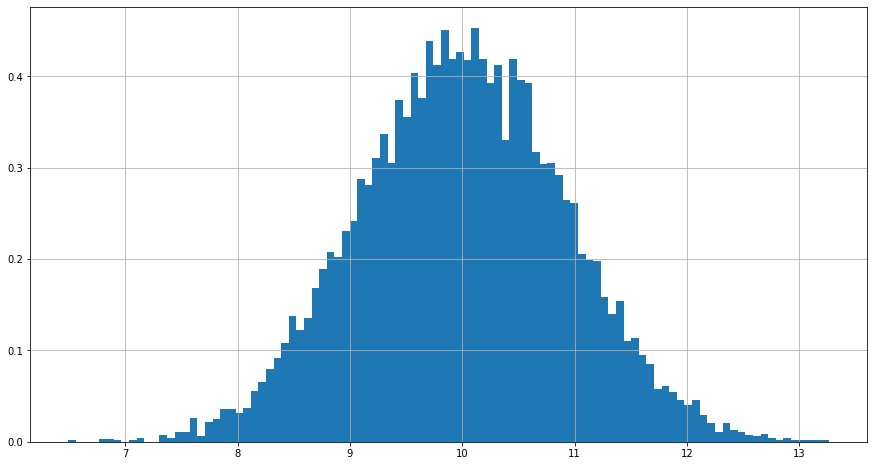

In [51]:
colecao['Lista_medias'].hist(bins=100, density=True, figsize=(15,8))

In [54]:
lista_variancias = []
for t in range(10000):
    amostra = pd.DataFrame(np.random.normal(10, 5, size=30))
    lista_variancias.append(amostra[0].var(ddof=1))
print(lista_variancias)

[31.427124690132516, 20.360576111594504, 24.005645661127108, 25.01683379282752, 28.545397205217387, 27.198810802128808, 30.72014032947828, 16.89581108150137, 26.901205499261618, 23.504811838409037, 25.960758988646415, 15.160778456647684, 28.620902280785252, 17.58886720870385, 32.278167449763494, 25.89041774400547, 22.357998492242217, 27.952201779129233, 23.985837678078877, 18.818253917677527, 23.90430868664628, 21.603496726498026, 24.056760872229486, 15.637538093953323, 16.1331407680916, 21.04467889463693, 25.776659388707827, 28.5810432721584, 16.273201681471576, 39.15264880397911, 29.41775619509709, 17.935403851257504, 28.250950863426766, 25.91485528573839, 31.65769467133255, 33.28125901928209, 21.9435991756057, 27.434770532373925, 15.688934747675566, 24.930556849175257, 19.84193732039242, 18.856063195575114, 27.133343195424192, 23.120676712168915, 30.64989351145411, 24.258916337738686, 39.074990996957524, 23.24194273303244, 36.27812614185391, 29.382033677074247, 30.332118000765885, 4

In [55]:
colecao = pd.DataFrame()
colecao['Lista_variancias'] = lista_variancias
colecao.head()

,Lista_variancias
0,31.427125
1,20.360576
2,24.005646
3,25.016834
4,28.545397


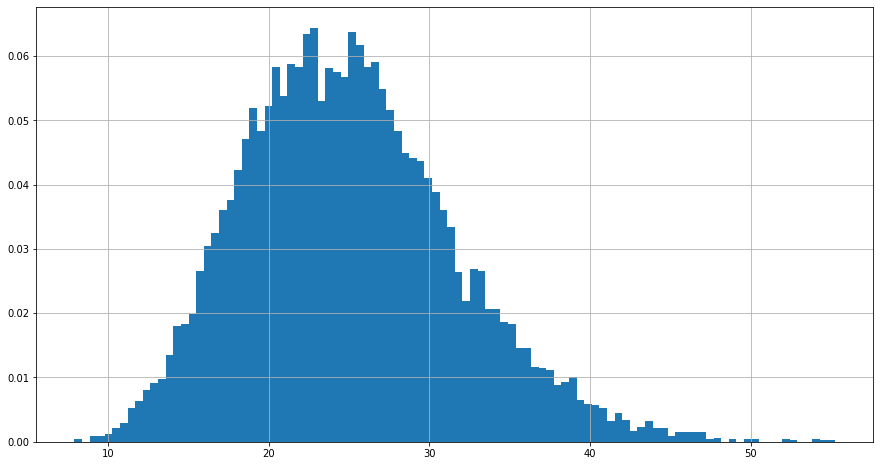

In [56]:
colecao['Lista_variancias'].hist(bins=100, density=True, figsize=(15,8))

0.6000370000000094


array([[<matplotlib.axes._subplots.AxesSubplot object at 0x7f74eab3ed10>]],
      dtype=object)

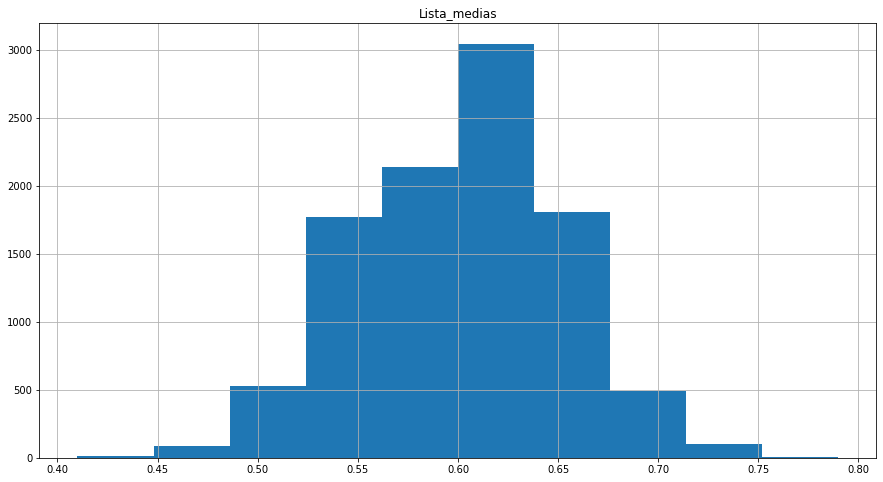

In [67]:
# Vamos observar o significado do Teorema do Limite Central com este exemplo
# Se a amostra é grande o bastante, a distribuição das médias amostrais é 
# aproximadamente normal mesmo quando a população escolhida não é normal*
# *Altere o tamanho da amostra para ver as mudanças e tente descobrir a partir 
# de qual valor a amostra se parece com uma distribuição normal

tamanho_amostra = 100
lista_medias_amostrais = []
populacao_anomala =  pd.DataFrame([1, 0, 1, 0, 1])
for t in range(10000):
    amostra = populacao_anomala[0].sample(tamanho_amostra, replace=True)  
    lista_medias_amostrais.append(amostra.mean())

colecao = pd.DataFrame()
colecao['Lista_medias'] = lista_medias_amostrais
print(colecao['Lista_medias'].mean())
colecao.hist(bins=10, density=False, figsize=(15,8))

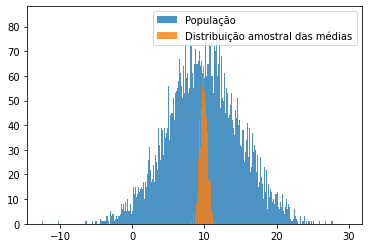

In [73]:
from matplotlib import pyplot as plt

tamanho_amostra = 100
lista_medias_amostrais = []
pop = pd.DataFrame(np.random.normal(10, 5, size=10000))

for t in range(10000):
    amostra = pop[0].sample(tamanho_amostra, replace=True)  
    lista_medias_amostrais.append(amostra.mean())

colecao = pd.DataFrame()
colecao['Lista_medias'] = lista_medias_amostrais

# bins = np.linspace(-30, 30, 500)

plt.hist(pop[0], bins=500, alpha=0.8, label='População')
plt.hist(colecao['Lista_medias'], bins=500, alpha=0.8, label='Distribuição amostral das médias')
plt.legend(loc='upper right')
plt.show()


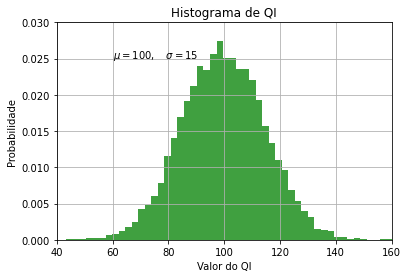

In [50]:
import numpy as np
import matplotlib.pyplot as plt

# Fixing random state for reproducibility
np.random.seed(19680801)

mu, sigma = 100, 15
x = mu + sigma * np.random.randn(10000)

# the histogram of the data
n, bins, patches = plt.hist(x, 50, density=True, facecolor='g', alpha=0.75)


plt.xlabel('Valor do QI')
plt.ylabel('Probabilidade')
plt.title('Histograma de QI')
plt.text(60, .025, r'$\mu=100,\quad \sigma=15$')
plt.xlim(40, 160)
plt.ylim(0, 0.03)
plt.grid(True)
plt.show()

In [ ]:
dados = pd.read_excel('dados.xlsx', index_col = 0)
dados.head(5)